In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dataset healthcare.csv')
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (5190, 13)

Missing Values:
 Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64


In [4]:
# Drop the 'Unnamed: 0' column as it's just a record identifier
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    visits  gender   age  income  illness  reduced  health private freepoor  \
0       1  female  0.19    0.55        1        4       1     yes       no   
1       1  female  0.19    0.45        1        2       1     yes       no   
2       1    male  0.19    0.90        3        0       0      no       no   
3       1    male  0.19    0.15        1        0       0      no       no   
4       1    male  0.19    0.45        2        5       1      no       no   

  freerepat nchronic lchronic  
0        no       no       no  
1        no       no       no  
2        no       no       no  
3        no       no       no  
4        no      yes       no  


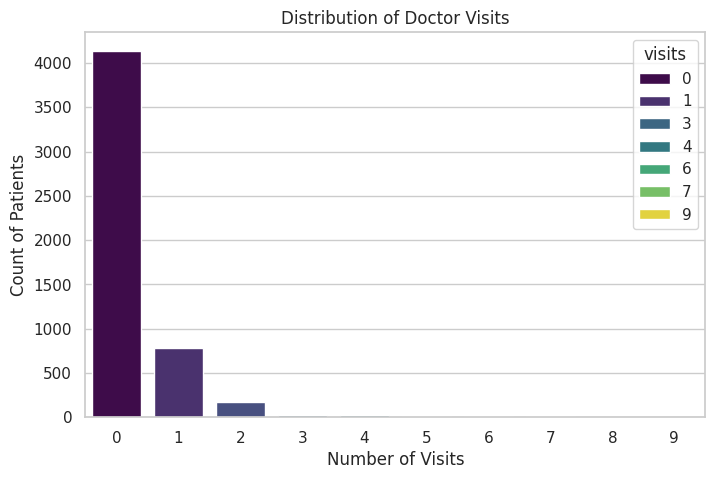

In [15]:
sns.set_theme(style="whitegrid")

# --- Univariate Analysis ---

# Distribution of Doctor Visits
plt.figure(figsize=(8, 5))
sns.countplot(x='visits', data=df, palette='viridis', hue="visits")
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count of Patients')
plt.show()

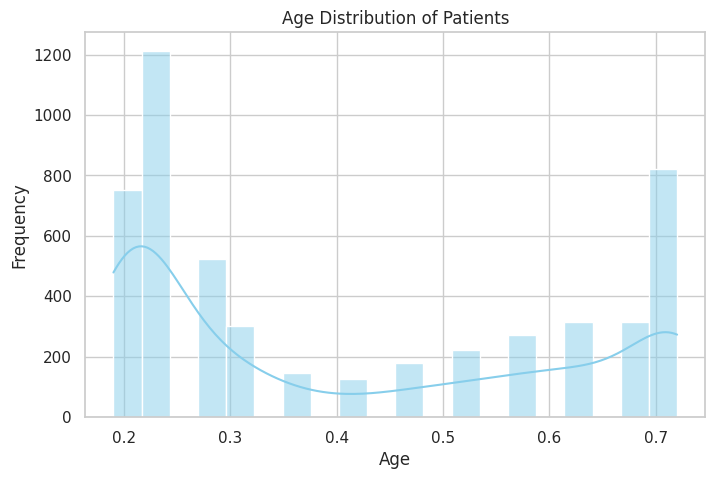

In [6]:
# Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

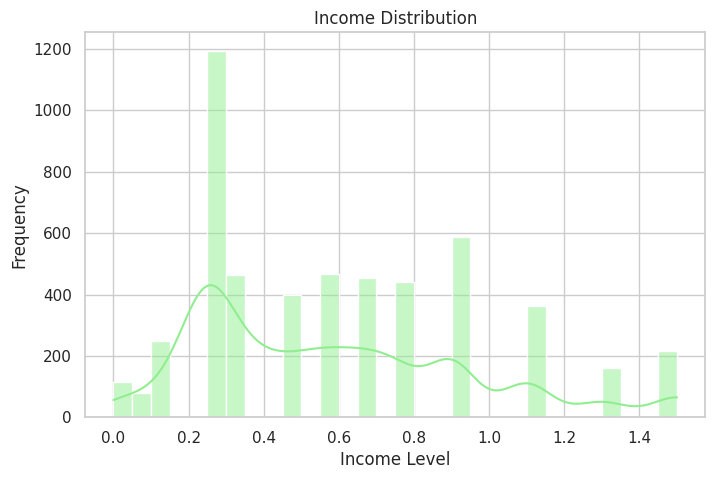

In [7]:
# Distribution of Income
plt.figure(figsize=(8, 5))
sns.histplot(df['income'], bins=30, kde=True, color='lightgreen')
plt.title('Income Distribution')
plt.xlabel('Income Level')
plt.ylabel('Frequency')
plt.show()

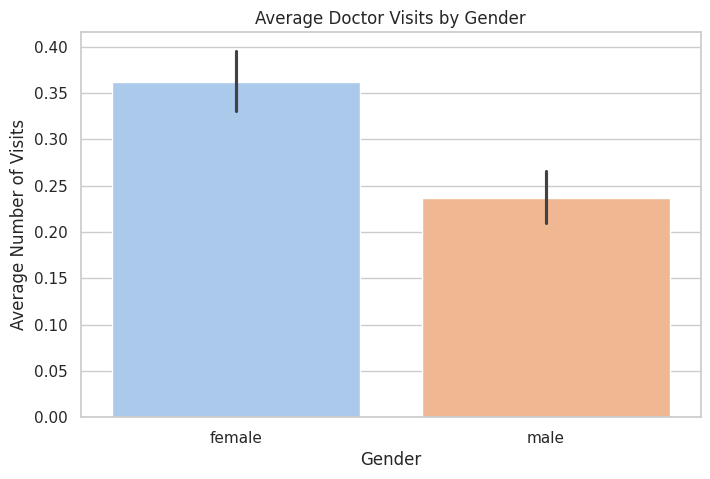

In [16]:
# --- Bivariate Analysis ---

# Doctor Visits by Gender
plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='visits', data=df, palette='pastel', hue="gender")
plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Number of Visits')
plt.show()

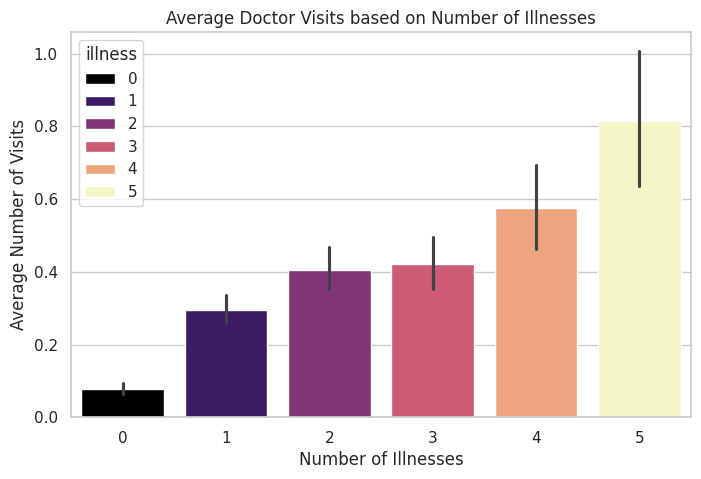

In [17]:
# Doctor Visits vs. Number of Illnesses
plt.figure(figsize=(8, 5))
sns.barplot(x='illness', y='visits', data=df, palette='magma', hue="illness")
plt.title('Average Doctor Visits based on Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Number of Visits')
plt.show()

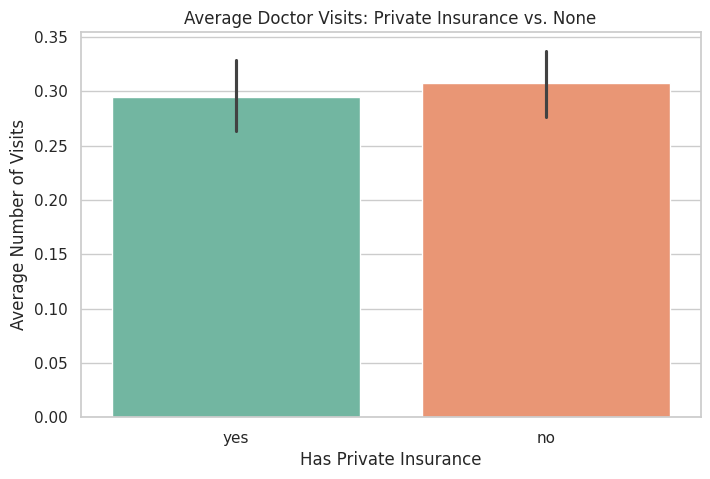

In [18]:
# Doctor Visits vs. Private Insurance
plt.figure(figsize=(8, 5))
sns.barplot(x='private', y='visits', data=df, palette='Set2', hue="private")
plt.title('Average Doctor Visits: Private Insurance vs. None')
plt.xlabel('Has Private Insurance')
plt.ylabel('Average Number of Visits')
plt.show()

In [11]:
# --- Multivariate Analysis ---

# Correlation Heatmap for numerical variables
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

<Figure size 1000x800 with 0 Axes>

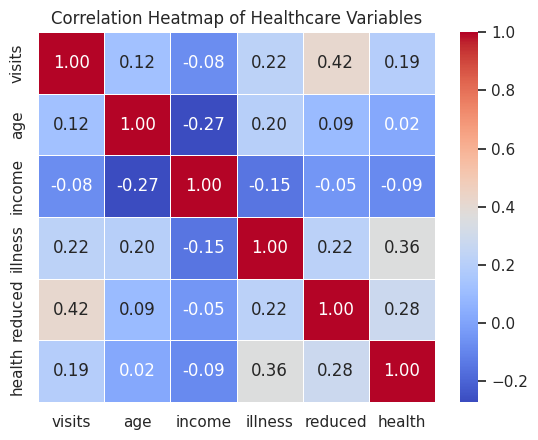

In [12]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Healthcare Variables')
plt.show()

# **Key Insights**

---


1.   A large portion of the dataset has 0 visits, indicating many individuals did not visit a doctor during this period.
2.   Females tend to have a slightly higher average number of doctor visits compared to males.
3.   There is a clear positive trend between the number of illnesses a patient has and their average number of doctor visits.
4.   The heatmap shows relationships between health status (illness, reduced days) and the frequency of visits.